# Notebook 06 — Hawkish-Dovish Tone Score for BIS Central Bank Speeches

**Objective.** This notebook constructs a **dictionary-based hawkish-dovish tone proxy** for central bank speeches. It is designed as an extension to the topic modeling analysis, not as a supervised stance classifier.

The goal is to answer a complementary question:

> Do central bank speeches become lexically more hawkish or more dovish across macro-financial periods?

The method is intentionally transparent and interpretable:

1. define a monetary-policy lexicon;
2. count hawkish and dovish terms/phrases;
3. normalize by document length;
4. aggregate by year and macro-financial period;
5. validate with face-validity checks and robustness diagnostics.

**Important scientific caveat.** This score is not a causal measure of monetary policy stance. It is a lexical tone proxy based on word usage.

## 1. Imports and data loading

The notebook expects the final preprocessed dataset produced by Notebook 02. It should contain at least:

- `clean_text`: lemmatized text used for NMF/LDA;
- `bertopic_text` or `raw_text`: less aggressively cleaned text used for phrase matching;
- `year`, `month`, `central_bank`, `description`.

In Google Colab, upload the CSV when prompted, or change `DATA_PATH` manually.

In [1]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

In [2]:
pd.set_option('display.max_colwidth', 160)

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Data/bis_speeches_preprocessed_CB.csv")
df.head()

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Mounted at /content/drive
Dataset shape: (18922, 11)
Columns: ['description', 'raw_text_stripped', 'clean_text', 'bertopic_text', 'central_bank', 'year', 'month', 'macro_period', 'n_words_raw', 'n_characters_raw', 'n_words_clean']


In [3]:
essential_cols = ["year", "central_bank", "clean_text"]
missing = [c for c in essential_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Ensure year is numeric
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year", "clean_text"]).copy()
df["year"] = df["year"].astype(int)

print("Number of speeches:", len(df))
print("Years:", df["year"].min(), "-", df["year"].max())
print("Distinct central banks:", df["central_bank"].nunique())

Number of speeches: 18922
Years: 1997 - 2025
Distinct central banks: 118


## 2. Macro-financial periods

The same periodization as in the topic modeling report is reused. This allows the tone score to be compared with topic prevalence by macro-financial regime.

In [4]:
def assign_macro_period(year: int) -> str:
    if 1997 <= year <= 2006:
        return "Pre-GFC"
    elif 2007 <= year <= 2009:
        return "Global Financial Crisis"
    elif 2010 <= year <= 2014:
        return "Euro crisis / post-GFC"
    elif 2015 <= year <= 2019:
        return "Low rates / QE"
    elif 2020 <= year <= 2021:
        return "Covid"
    elif 2022 <= year <= 2025:
        return "Inflation tightening"
    else:
        return "Other"

period_order = [
    "Pre-GFC",
    "Global Financial Crisis",
    "Euro crisis / post-GFC",
    "Low rates / QE",
    "Covid",
    "Inflation tightening"
]

df["macro_period"] = df["year"].apply(assign_macro_period)
print(df["macro_period"].value_counts().reindex(period_order))

macro_period
Pre-GFC                    3708
Global Financial Crisis    2517
Euro crisis / post-GFC     4716
Low rates / QE             4521
Covid                      1264
Inflation tightening       2196
Name: count, dtype: int64


## 3. Hawkish and dovish lexicon

The lexicon is deliberately small and monetary-policy oriented. It combines:

- **single-token terms** matched on the lemmatized `clean_text` column;
- **multi-word phrases** matched on the less-cleaned text column.

Multi-word expressions receive a larger weight because they are usually less ambiguous than isolated words. For example, `tighten monetary policy` is more informative than the isolated word `policy`.

The score is still a proxy. Words such as `inflation` or `support` can appear in different contexts. This is why the notebook includes robustness and qualitative validation steps.

In [5]:
# Lemmatized single-token terms expected to appear in clean_text
hawkish_terms = {
    # monetary restriction / hikes
    "tighten", "tightening", "restrictive", "restriction", "hike", "raise", "increase",
    "normalization", "normalize", "withdraw", "restraint", "firm",
    # inflation pressure / credibility vocabulary
    "inflation", "inflationary", "overheating", "pressure", "persistent", "persistence",
    "elevated", "wage", "anchor", "credibility", "vigilance", "upside",
    # price stability vocabulary
    "price", "stability", "target"
}

dovish_terms = {
    # easing / accommodation
    "ease", "easing", "accommodative", "accommodation", "stimulus", "support",
    "cut", "lower", "reduction", "purchase", "liquidity", "qe",
    # weak activity / slack
    "slack", "weak", "weakness", "recession", "downturn", "slowdown", "unemployment",
    "deflation", "disinflation", "downside", "recovery"
}

# Multi-word phrases matched on natural text. These are more specific.
hawkish_phrases = [
    "tighten monetary policy", "tightening monetary policy", "raise rates", "raise interest rates",
    "increase rates", "increase interest rates", "rate hikes", "policy tightening",
    "monetary tightening", "restrictive policy", "restrictive monetary policy",
    "policy normalization", "normalization of monetary policy", "inflation pressures",
    "price pressures", "wage pressures", "second round effects", "upside risks",
    "above target", "fight inflation", "bring inflation down", "anchor inflation expectations"
]

dovish_phrases = [
    "ease monetary policy", "monetary easing", "policy easing", "cut rates", "cut interest rates",
    "lower rates", "lower interest rates", "accommodative policy", "accommodative monetary policy",
    "policy accommodation", "quantitative easing", "asset purchases", "downside risks",
    "economic slack", "weak demand", "support the economy", "support growth", "below target",
    "provide liquidity", "liquidity support", "stimulus measures"
]

print("Hawkish single terms:", len(hawkish_terms))
print("Dovish single terms:", len(dovish_terms))
print("Hawkish phrases:", len(hawkish_phrases))
print("Dovish phrases:", len(dovish_phrases))

Hawkish single terms: 27
Dovish single terms: 23
Hawkish phrases: 22
Dovish phrases: 21


## 4. Scoring function

For each speech, the notebook computes:

\[
\text{tone}_{d} = 1000 \times \frac{H_d - D_d}{N_d},
\]

where \(H_d\) is the weighted number of hawkish matches, \(D_d\) is the weighted number of dovish matches, and \(N_d\) is the number of cleaned tokens.

The multiplication by 1000 makes the score interpretable as a net hawkish count per 1,000 words.

A second bounded score is also computed:

\[
\text{balance}_{d} = \frac{H_d - D_d}{H_d + D_d + 1}.
\]

This is useful as a robustness check because it depends less directly on speech length.

In [6]:
# Choose a text column for phrase matching
if "bertopic_text" in df.columns:
    phrase_col = "bertopic_text"
elif "raw_text" in df.columns:
    phrase_col = "raw_text"
else:
    phrase_col = "clean_text"

print("Phrase matching column:", phrase_col)

# Compile phrase regexes with word boundaries. Hyphens are normalized to spaces.
def normalize_for_phrases(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[-–—]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def count_phrase_matches(text: str, phrases) -> Counter:
    text = normalize_for_phrases(text)
    counts = Counter()
    for phrase in phrases:
        pattern = r"\b" + re.escape(phrase.lower()).replace("\\ ", r"\s+") + r"\b"
        n = len(re.findall(pattern, text))
        if n:
            counts[phrase] = n
    return counts

def count_term_matches(clean_text: str, terms) -> Counter:
    tokens = str(clean_text).split()
    token_counts = Counter(tokens)
    return Counter({t: token_counts[t] for t in terms if token_counts[t] > 0})

PHRASE_WEIGHT = 2.0

def score_document(row):
    clean_text = row["clean_text"]
    natural_text = row[phrase_col]
    tokens = str(clean_text).split()
    n_tokens = len(tokens)

    hawk_terms = count_term_matches(clean_text, hawkish_terms)
    dov_terms = count_term_matches(clean_text, dovish_terms)
    hawk_phr = count_phrase_matches(natural_text, hawkish_phrases)
    dov_phr = count_phrase_matches(natural_text, dovish_phrases)

    hawk_count = sum(hawk_terms.values()) + PHRASE_WEIGHT * sum(hawk_phr.values())
    dov_count = sum(dov_terms.values()) + PHRASE_WEIGHT * sum(dov_phr.values())

    if n_tokens == 0:
        tone_per_1000 = np.nan
    else:
        tone_per_1000 = 1000.0 * (hawk_count - dov_count) / n_tokens

    balance_score = (hawk_count - dov_count) / (hawk_count + dov_count + 1.0)

    return pd.Series({
        "n_tokens_clean": n_tokens,
        "hawkish_count": hawk_count,
        "dovish_count": dov_count,
        "tone_per_1000": tone_per_1000,
        "balance_score": balance_score,
        "hawkish_terms_matched": ", ".join([f"{k}:{v}" for k, v in (hawk_terms + hawk_phr).most_common(10)]),
        "dovish_terms_matched": ", ".join([f"{k}:{v}" for k, v in (dov_terms + dov_phr).most_common(10)])
    })

score_cols = df.apply(score_document, axis=1)
df_tone = pd.concat([df.reset_index(drop=True), score_cols.reset_index(drop=True)], axis=1)

print(df_tone[["n_tokens_clean", "hawkish_count", "dovish_count", "tone_per_1000", "balance_score"]].describe())

Phrase matching column: bertopic_text
       n_tokens_clean  hawkish_count  dovish_count  tone_per_1000  \
count    18922.000000   18922.000000  18922.000000   18922.000000   
mean      1255.447151      38.735387     16.087887      16.472907   
std        830.657344      49.310596     21.382776      25.773705   
min        101.000000       0.000000      0.000000     -77.669903   
25%        687.000000       8.000000      4.000000       1.324942   
50%       1093.000000      22.000000      9.000000       8.880995   
75%       1640.750000      49.000000     20.000000      24.202154   
max      27117.000000     804.000000    470.000000     177.051672   

       balance_score  
count   18922.000000  
mean        0.322016  
std         0.381745  
min        -0.923077  
25%         0.062500  
50%         0.375000  
75%         0.625000  
max         0.994536  


## 5. Lexicon sanity checks

Before interpreting the score, it is important to verify which terms actually drive it. If the score is dominated by one ambiguous term, the lexicon should be revised.

In [7]:
# Aggregate matched terms for diagnostic purposes
hawk_total = Counter()
dov_total = Counter()

for _, row in df.iterrows():
    hawk_total.update(count_term_matches(row["clean_text"], hawkish_terms))
    hawk_total.update(count_phrase_matches(row[phrase_col], hawkish_phrases))
    dov_total.update(count_term_matches(row["clean_text"], dovish_terms))
    dov_total.update(count_phrase_matches(row[phrase_col], dovish_phrases))

hawk_freq = pd.DataFrame(hawk_total.most_common(25), columns=["term_or_phrase", "count"])
dov_freq = pd.DataFrame(dov_total.most_common(25), columns=["term_or_phrase", "count"])

print("Most frequent hawkish matches")
display(hawk_freq)
print("Most frequent dovish matches")
display(dov_freq)

Most frequent hawkish matches


,term_or_phrase,count
0,inflation,155096
1,price,138431
2,increase,111689
3,stability,87209
4,firm,47927
5,target,47437
6,pressure,24298
7,wage,23025
8,raise,22309
9,inflationary,8039


Most frequent dovish matches


,term_or_phrase,count
0,support,48145
1,liquidity,43254
2,recovery,25841
3,purchase,21704
4,unemployment,18547
5,weak,12620
6,recession,10747
7,reduction,10741
8,cut,8467
9,ease,7896


## 6. Distribution of the tone score

This plot checks whether the tone score has extreme outliers. The notebook also creates a winsorized score to make yearly averages more robust.

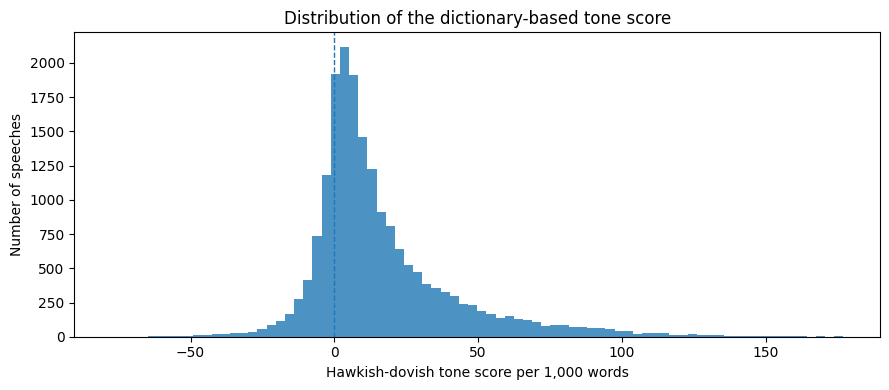

Winsorization bounds: -25.393227726636958 109.44425379571338


In [8]:
# Winsorize the score at 1% and 99% to reduce the impact of extreme short/specific speeches
lower, upper = df_tone["tone_per_1000"].quantile([0.01, 0.99])
df_tone["tone_per_1000_w"] = df_tone["tone_per_1000"].clip(lower, upper)

plt.figure(figsize=(9, 4))
plt.hist(df_tone["tone_per_1000"].dropna(), bins=80, alpha=0.8)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Hawkish-dovish tone score per 1,000 words")
plt.ylabel("Number of speeches")
plt.title("Distribution of the dictionary-based tone score")
plt.tight_layout()
plt.show()

print("Winsorization bounds:", lower, upper)

## 7. Temporal evolution of hawkish-dovish tone

The main object of interest is the average tone by year. The score is interpreted as a change in communication emphasis, not as a direct policy stance measure.

,year,n_speeches,mean_tone,median_tone,std_tone,mean_balance,se_tone,ci_low,ci_high
24,2021,619,10.441476,5.043228,20.854871,0.202537,0.838228,8.798549,12.084403
25,2022,725,28.337828,15.714286,32.995585,0.413560,1.225425,25.935994,30.739661
26,2023,730,32.086873,18.944177,35.853508,0.441459,1.326998,29.485957,34.687788
27,2024,697,22.238021,11.292346,29.882666,0.345674,1.131887,20.019523,24.456519
28,2025,44,21.621513,11.398127,30.144204,0.321479,4.544410,12.714470,30.528556


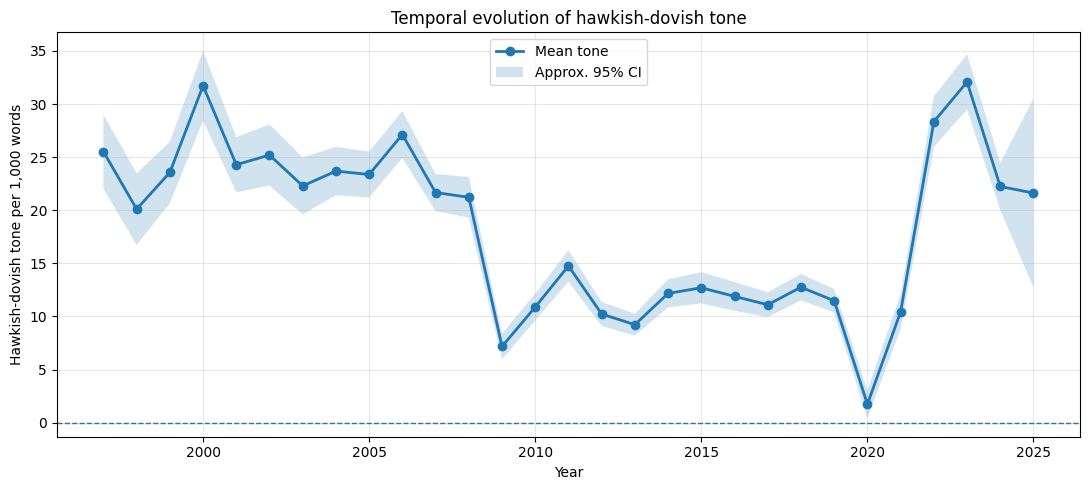

In [9]:
yearly = (
    df_tone
    .groupby("year")
    .agg(
        n_speeches=("tone_per_1000_w", "size"),
        mean_tone=("tone_per_1000_w", "mean"),
        median_tone=("tone_per_1000_w", "median"),
        std_tone=("tone_per_1000_w", "std"),
        mean_balance=("balance_score", "mean")
    )
    .reset_index()
)
yearly["se_tone"] = yearly["std_tone"] / np.sqrt(yearly["n_speeches"])
yearly["ci_low"] = yearly["mean_tone"] - 1.96 * yearly["se_tone"]
yearly["ci_high"] = yearly["mean_tone"] + 1.96 * yearly["se_tone"]

display(yearly.tail())

plt.figure(figsize=(11, 5))
plt.plot(yearly["year"], yearly["mean_tone"], marker="o", linewidth=2, label="Mean tone")
plt.fill_between(yearly["year"], yearly["ci_low"], yearly["ci_high"], alpha=0.2, label="Approx. 95% CI")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Hawkish-dovish tone per 1,000 words")
plt.title("Temporal evolution of hawkish-dovish tone")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hawkish_dovish_tone_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Macro-period comparison

This aggregates the score by the same macro-financial periods used in the topic modeling report. A scientifically plausible pattern would be relatively more hawkish tone during the recent inflation-tightening period and relatively more dovish/accommodative tone around Covid or low-rate periods.

,macro_period,n_speeches,mean_tone,median_tone,mean_balance,mean_hawkish_count,mean_dovish_count
0,Pre-GFC,3708,24.826838,16.199039,0.484593,45.768339,11.580636
1,Global Financial Crisis,2517,16.736769,9.606987,0.327207,39.254271,15.702026
2,Euro crisis / post-GFC,4716,11.428866,6.737254,0.254444,35.061069,18.716921
3,Low rates / QE,4521,11.966445,6.926952,0.273448,34.326919,16.846494
4,Covid,1264,5.996698,3.072512,0.126066,30.162184,21.395570
5,Inflation tightening,2196,27.513474,14.847769,0.399443,48.166667,13.877960


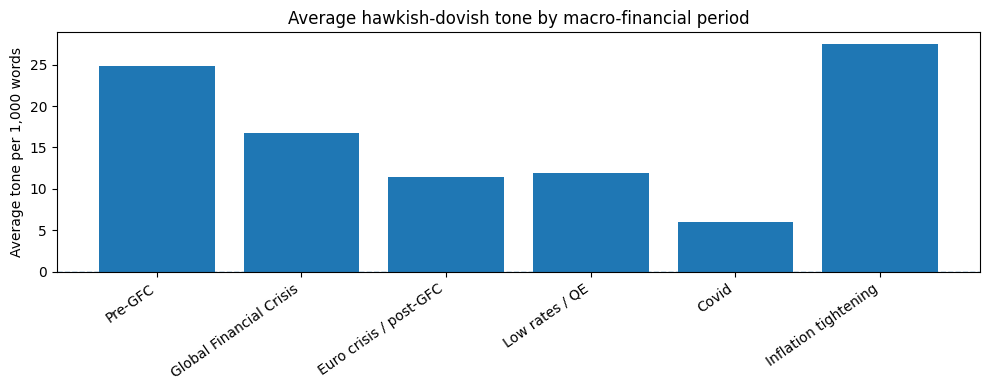

In [10]:
period_summary = (
    df_tone[df_tone["macro_period"].isin(period_order)]
    .groupby("macro_period")
    .agg(
        n_speeches=("tone_per_1000_w", "size"),
        mean_tone=("tone_per_1000_w", "mean"),
        median_tone=("tone_per_1000_w", "median"),
        mean_balance=("balance_score", "mean"),
        mean_hawkish_count=("hawkish_count", "mean"),
        mean_dovish_count=("dovish_count", "mean")
    )
    .reindex(period_order)
    .reset_index()
)

display(period_summary)

plt.figure(figsize=(10, 4))
plt.bar(period_summary["macro_period"], period_summary["mean_tone"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Average tone per 1,000 words")
plt.title("Average hawkish-dovish tone by macro-financial period")
plt.tight_layout()
plt.savefig("hawkish_dovish_tone_by_period.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Qualitative validation: most hawkish and most dovish speeches

A dictionary score is only useful if its most extreme speeches are plausible. This cell inspects the speeches with the highest and lowest scores.

In [11]:
cols_to_show = [c for c in [
    "year", "month", "central_bank", "description", "tone_per_1000_w",
    "hawkish_count", "dovish_count", "hawkish_terms_matched", "dovish_terms_matched"
] if c in df_tone.columns]

print("Most hawkish speeches")
display(df_tone.sort_values("tone_per_1000_w", ascending=False)[cols_to_show].head(10))

print("Most dovish speeches")
display(df_tone.sort_values("tone_per_1000_w", ascending=True)[cols_to_show].head(10))

Most hawkish speeches


,year,month,central_bank,description,tone_per_1000_w,hawkish_count,dovish_count,hawkish_terms_matched,dovish_terms_matched
10673,2006,7,bank of england,"Speech by Sir John Gieve, Deputy Governor of the Bank of England, to the Engineering Employers' Federation North West, Warrington, 20 July 2006.",109.444254,152.0,8.0,"price:45, inflation:44, target:13, stability:11, wage:9, pressure:8, increase:8, inflationary:3, firm:2, hike:2","lower interest rates:2, disinflation:1, unemployment:1, cut:1, ease:1"
5294,2005,5,board of governors of the federal reserve system,"Remarks by Mr Edward M Gramlich, Member of the Board of Governors of the US Federal Reserve System, at the Euromoney Inflation Conference, Paris, 26 May 2005.",109.444254,240.0,15.0,"inflation:101, target:87, price:23, stability:21, inflationary:4, raise:2, firm:1, wage:1","unemployment:7, support:6, weak:1, lower:1"
2805,2023,4,bank of canada,"Opening statement by Mr Tiff Macklem, Governor of the Bank of Canada, at the press conference following the release of the Monetary Policy Report, Ottawa, O...",109.444254,96.0,14.0,"inflation:34, price:15, target:12, increase:6, restrictive:4, stability:3, upside:3, tighten:2, normalize:2, wage:2","weak:4, ease:4, support:1, easing:1, slowdown:1, unemployment:1, recession:1, downside:1"
2816,2023,11,bank of canada,"Opening statement by Mr Tiff Macklem, Governor of the Bank of Canada, before the Standing Senate Committee on Banking, Commerce and the Economy, Ottawa, Ont...",109.444254,59.0,7.0,"inflation:19, price:12, increase:6, pressure:4, inflationary:3, stability:3, elevated:2, price pressures:2, normalize:1, persistence:1","ease:4, weak:2, easing:1"
2817,2023,11,bank of canada,"Remarks by Mr Tiff Macklem, Governor of the Bank of Canada, at the Saint John Region Chamber of Commerce, Saint John, New Brunswick, 22 November 2023.",109.444254,132.0,12.0,"inflation:61, price:17, raise:11, target:11, increase:7, stability:4, pressure:3, tightening:3, wage:2, tighten:1","unemployment:4, recession:3, slowdown:1, weak:1, lower:1, purchase:1, recovery:1"
2818,2023,12,bank of canada,"Remarks by Mr Tiff Macklem, Governor of the Bank of Canada, at the Canadian Club Toronto, Toronto, Ontario, 15 December 2023.",109.444254,157.0,15.0,"inflation:59, price:31, stability:11, pressure:10, target:10, increase:10, inflationary:4, anchor:4, firm:2, wage:2","ease:4, weak:2, lower:2, reduction:1, unemployment:1, weakness:1, cut:1, recovery:1, weak demand:1"
2819,2024,1,bank of canada,"Opening statement by Mr Tiff Macklem, Governor of the Bank of Canada, at the press conference following the release of the Monetary Policy Report, Ottawa, O...",109.444254,74.0,9.0,"inflation:23, price:9, pressure:9, inflationary:4, target:4, increase:3, restrictive:3, price pressures:3, normalize:2, tightening:2","ease:4, weak:2, easing:1, weak demand:1"
2820,2024,2,bank of canada,"Opening statement by Mr Tiff Macklem, Governor of the Bank of Canada, before the House of Commons Standing Committee on Finance, Ottawa, Ontario, 1 February...",109.444254,72.0,8.0,"inflation:22, price:9, pressure:9, inflationary:4, target:3, increase:3, restrictive:3, price pressures:3, normalize:2, tightening:2","ease:3, weak:2, easing:1, weak demand:1"
2821,2024,3,bank of canada,"Opening statement by Mr Tiff Macklem, Governor of the Bank of Canada, at the press conference following the monetary policy decision, Ottawa, Ontario, 6 Mar...",109.444254,83.0,15.0,"inflation:24, price:14, pressure:8, inflationary:3, wage:3, stability:3, restrictive:3, price pressures:3, increase:2, elevated:2","ease:10, weak:2, easing:1, lower:1, weakness:1"
2790,2022,10,bank of canada,"Remarks by Mr Tiff Macklem, Governor of the Bank of Canada, at the Halifax Chamber of Commerce, Halifax, Nova Scotia, 6 October 2022.",109.444254,220.0,19.0,"inflation:98, price:43, pressure:16, increase:10, target:9, inflationary:8, stability:5, wage:4, raise:4, anchor:3","ease:11, deflation:2, support:1, lower:1, recession:1,

Most dovish speeches


,year,month,central_bank,description,tone_per_1000_w,hawkish_count,dovish_count,hawkish_terms_matched,dovish_terms_matched
13481,2019,11,european central bank,"Speech by Mr Benoît Cœuré, Member of the Executive Board of the European Central Bank, at the European Central Bank workshop on money markets, monetary poli...",-25.393228,30.0,75.0,"increase:14, pressure:7, target:2, stability:2, inflation:2, raise:1, elevated:1, anchor:1","liquidity:63, purchase:5, accommodative:2, reduction:1, accommodative monetary policy:1, asset purchases:1"
10822,2012,2,bank of england,"Speech by Mr Charles Bean, Deputy Governor for Monetary Policy of the Bank of England, to the Scottish Council for Development and Industry, Glasgow, 21 Feb...",-25.393228,28.0,70.0,"price:8, increase:7, raise:3, inflation:3, pressure:2, withdraw:1, firm:1, target:1, stability:1, tightening:1","purchase:14, easing:11, quantitative easing:11, recovery:4, asset purchases:4, weak:3, stimulus:3, unemployment:2, weakness:1, downside:1"
15795,2012,10,federal reserve bank of new york,"Remarks by Mr William C Dudley, President and Chief Executive Officer of the Federal Reserve Bank of New York and Chairman of the Committee on the Global Fi...",-25.393228,43.0,128.0,"increase:13, inflation:7, price:6, raise:5, restraint:2, elevated:2, normalization:1, inflationary:1, credibility:1, hike:1","recovery:26, purchase:18, support:12, stimulus:8, weak:7, accommodative:6, asset purchases:6, unemployment:4, cut:4, ease:4"
14260,2023,11,swiss national bank,"Summary of the keynote speech by Mr Thomas Jordan, Chairman of the Governing Board of the Swiss National Bank, at the conference ""The SNB and its Watchers"",...",-25.393228,7.0,27.0,stability:7,"liquidity:22, provide liquidity:2, support:1"
14263,2023,11,swiss national bank,"Introductory remarks by Mr Martin Schlegel, Vice Chairman of the Governing Board of the Swiss National Bank, to the ""Alumni WWZ Basel"" (Faculty of Business ...",-25.393228,14.0,107.0,"stability:5, increase:3, restriction:2, withdraw:2, firm:1, pressure:1","liquidity:82, support:6, provide liquidity:6, liquidity support:3, reduction:1"
5991,2015,11,board of governors of the federal reserve system,"Speech by Ms Lael Brainard, Member of the Board of Governors of the Federal Reserve System, at the 16th International Monetary Fund Jacques Polak Research C...",-25.393228,36.0,96.0,"inflation:7, target:5, increase:5, price:4, pressure:4, raise:3, tightening:3, restraint:1, persistent:1, stability:1","purchase:22, asset purchases:15, easing:7, support:6, ease:6, lower:5, reduction:4, accommodation:4, recession:2, liquidity:1"
15804,2013,4,federal reserve bank of new york,"Remarks by Mr Simon M Potter, Executive Vice President of the Markets Group of the Federal Reserve Bank of New York, at the Forecasters Club of New York, Ne...",-25.393228,30.0,177.0,"price:13, increase:9, raise:2, stability:2, inflation:2, pressure:1, target:1","purchase:101, asset purchases:15, liquidity:11, lower:6, support:5, accommodation:4, ease:4, policy accommodation:4, easing:1, downside:1"
17987,2007,11,bank of france,"Remarks by Mr Jean-Pierre Landau, Deputy Governor of the Bank of France, at the Paris EUROPLACE, Financial Forum, New York, 22 October 2007.",-25.393228,6.0,27.0,"price:3, increase:3","liquidity:21, support:2, liquidity support:2"
1441,2002,2,south african reserve bank,"Speech by Mr T T Mboweni, Governor of the South African Reserve Bank, at the Nieman Society of Southern Africa Annual Dinner, Cape Town, 9 February 2002.",-25.393228,35.0,78.0,"increase:18, price:11, raise:2, pressure:2, inflation:1, upside:1","recovery:22, recession:16, downturn:15, slowdown:4, weakness:4, stimulus:3, weak:2, deflation:2, unemployment:2, downside:2"
12115,2009,9,european central bank,"Speech by Mr Jose Manuel Gonzalez-Paramo, Member of the Executive Board of the European Central Bank, at the CFS conference ""The ECB and its Watchers XI"", F...",-25.393228,8.0,42.0,"stability:4, increase:2

## 10. Robustness: alternative score without phrase weighting

This robustness check computes an alternative score using only single-token terms. If the original and alternative scores are strongly correlated, the results are not driven only by phrase weighting.

Pearson correlation: 0.989
Spearman correlation: 0.984


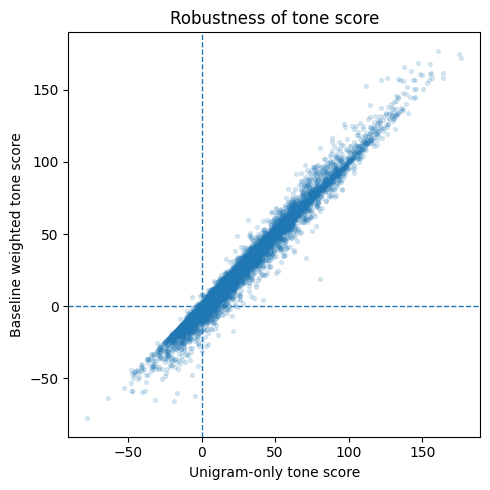

In [12]:
def score_document_unigrams_only(row):
    clean_text = row["clean_text"]
    tokens = str(clean_text).split()
    n_tokens = len(tokens)
    hawk_terms = count_term_matches(clean_text, hawkish_terms)
    dov_terms = count_term_matches(clean_text, dovish_terms)
    h = sum(hawk_terms.values())
    d = sum(dov_terms.values())
    return 1000.0 * (h - d) / n_tokens if n_tokens else np.nan

df_tone["tone_unigrams_only"] = df_tone.apply(score_document_unigrams_only, axis=1)

corr_pearson = df_tone[["tone_per_1000", "tone_unigrams_only"]].corr(method="pearson").iloc[0, 1]
corr_spearman = df_tone[["tone_per_1000", "tone_unigrams_only"]].corr(method="spearman").iloc[0, 1]
print("Pearson correlation:", round(corr_pearson, 3))
print("Spearman correlation:", round(corr_spearman, 3))

plt.figure(figsize=(5, 5))
plt.scatter(df_tone["tone_unigrams_only"], df_tone["tone_per_1000"], alpha=0.15, s=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Unigram-only tone score")
plt.ylabel("Baseline weighted tone score")
plt.title("Robustness of tone score")
plt.tight_layout()
plt.show()

## 11. Simple period validity check

This is not a causal test. It is a face-validity check: the recent inflation-tightening period should have a higher average hawkish tone than the Covid period if the score captures a meaningful monetary-policy signal.

In [13]:
comparison_periods = ["Covid", "Inflation tightening"]
subset = df_tone[df_tone["macro_period"].isin(comparison_periods)].copy()

means = subset.groupby("macro_period")["tone_per_1000_w"].mean().reindex(comparison_periods)
print(means)
print("Inflation tightening minus Covid:", means.loc["Inflation tightening"] - means.loc["Covid"])

try:
    from scipy.stats import ttest_ind, mannwhitneyu
    covid_scores = subset.loc[subset["macro_period"] == "Covid", "tone_per_1000_w"].dropna()
    tightening_scores = subset.loc[subset["macro_period"] == "Inflation tightening", "tone_per_1000_w"].dropna()
    t_stat, p_val = ttest_ind(tightening_scores, covid_scores, equal_var=False)
    u_stat, u_p = mannwhitneyu(tightening_scores, covid_scores, alternative="two-sided")
    print("Welch t-test: t =", round(t_stat, 3), "p =", round(p_val, 4))
    print("Mann-Whitney U: U =", round(u_stat, 1), "p =", round(u_p, 4))
except Exception as e:
    print("scipy not available; skipping formal tests.")

macro_period
Covid                    5.996698
Inflation tightening    27.513474
Name: tone_per_1000_w, dtype: float64
Inflation tightening minus Covid: 21.516776013081156
Welch t-test: t = 23.978 p = 0.0
Mann-Whitney U: U = 1961963.5 p = 0.0


## 12. Optional: relation with topics

If you have document-level topic weights from NMF or LDA in a CSV, you can merge them here and check whether the tone score is higher in inflation-related topics. This is optional and not required for the main report.

In [14]:
# Example optional merge skeleton. Uncomment and adapt if you exported document-level NMF/LDA topic weights.
# topic_path = "nmf_document_topics.csv"
# if os.path.exists(topic_path):
#     df_topics = pd.read_csv(topic_path)
#     # Make sure there is a common document id before merging.
#     display(df_topics.head())
# else:
#     print("No document-level topic file found. Optional section skipped.")